# Stage 4 — Harper–Hofstadter bulk figure workflow

- Gabriel Wendell Celestino Rocha
---

This teaching notebook is a front end to the tested `qhe` package. It does **not** reimplement the magnetic Bloch Hamiltonian, FHS algorithm, or Kubo formula. The publication renderer remains `scripts/make_main_figures.py`; this notebook explains the physics and reproduces the same type of validated figure from the reusable API.

## Objectives

1. identify the magnetic Brillouin zone for rational flux;
2. verify the three-band Chern sequence at $\phi=1/3$;
3. distinguish band dispersion from curvature-density validation;
4. regenerate a title-free bulk-band figure using a tested source builder.

In [1]:
import numpy as np

from qhe.models import HarperHofstadterParameters, magnetic_brillouin_zone
from qhe.topology import analyze_harper_hofstadter_topology, harper_hofstadter_convergence
from qhe.viz import plot_fhs_kubo_validation, plot_hofstadter_bulk_bands
from qhe.viz.style import set_style

set_style(context="notebook", use_tex=False, grid=False)

In [4]:
params = HarperHofstadterParameters(p=1, q=3, tx=1.0, ty=1.0)
zone = magnetic_brillouin_zone(params)
analysis = analyze_harper_hofstadter_topology(params, nkx=41, nky=41)

print("> Magnetic Brillouin zone:")
print(f"  - kx in [{zone.kx_min:.6f}, {zone.kx_max:.6f})")
print(f"  - ky in [{zone.ky_min:.6f}, {zone.ky_max:.6f})")
print("> FHS Chern numbers:", np.rint(analysis.fhs.chern_numbers).astype(int))
print("> Minimum direct gaps:", analysis.kubo.minimum_direct_gaps)

> Magnetic Brillouin zone:
  - kx in [-1.047198, 1.047198)
  - ky in [-3.141593, 3.141593)
> FHS Chern numbers: [-1  2 -1]
> Minimum direct gaps: [1.26794919 1.27257008]


## Magnetic subbands and Chern labels

The following plot is the source-controlled bulk-band visual. It follows a closed path in the magnetic Brillouin zone. The Chern labels come from the independently validated FHS calculation, not from a visual inference.

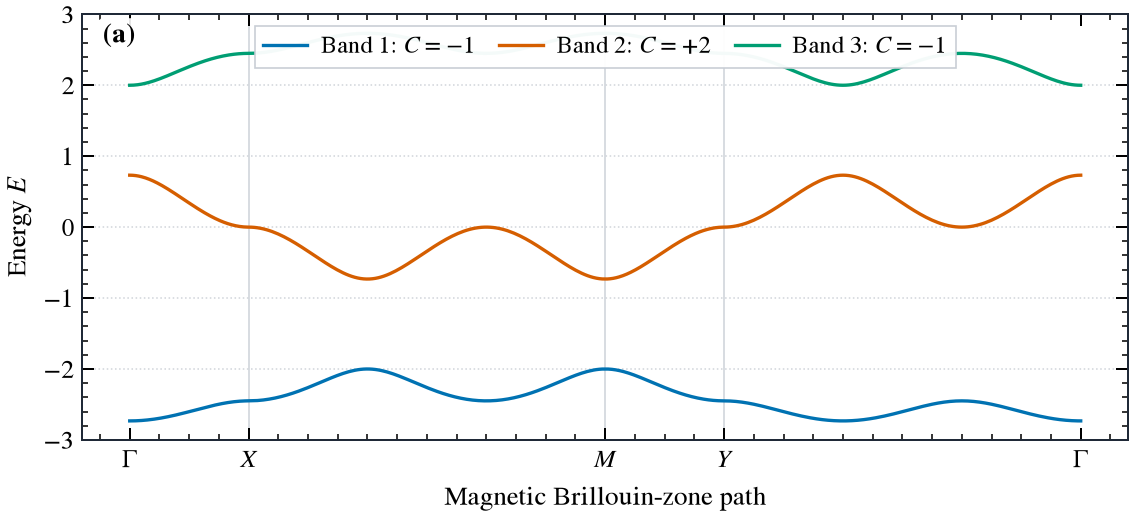

In [6]:
figure, axis = plot_hofstadter_bulk_bands(analysis, params, context="notebook")

## Curvature-density validation

FHS returns a discrete plaquette flux. For a fair comparison, the Kubo curvature is averaged on the same plaquettes before the residual is calculated. The first two map panels therefore share the same colour normalization.

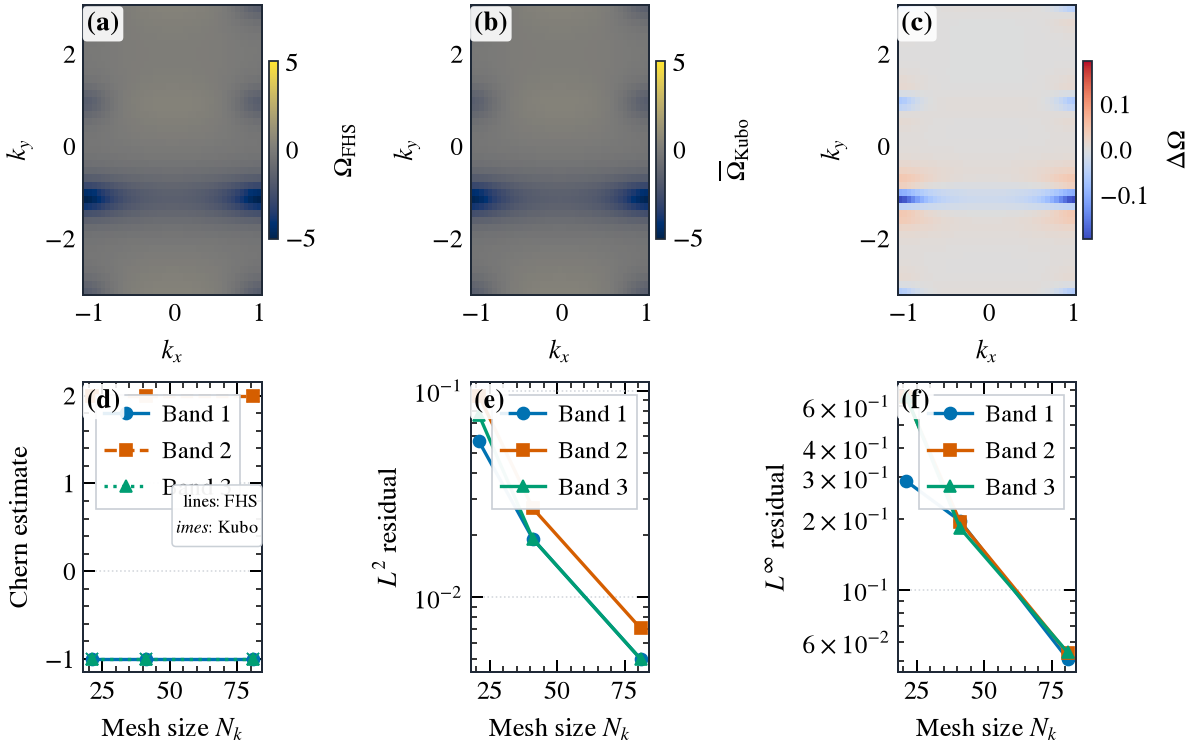

In [8]:
convergence = harper_hofstadter_convergence(params, mesh_sizes = (21, 41, 81))
figure, axes = plot_fhs_kubo_validation(analysis, convergence, band_index = 0, context = "notebook")

---